# 1) Python basics for ML (syntax + mental model)

Goal: learn the Python pieces you’ll use constantly in ML/DL notebooks:
- important librarie snumpy, pandas, matplotlib
- Variables + types
- Mutability vs immutability (a common bug source)
- Core data types + conversions
- Collections (list/tuple/dict/set)
- Operators
- Indentation + control flow


In [145]:
from pprint import pprint

In [146]:
config = {
    "epochs": 10,
    "optimizer": {"name": "adam", "lr": 0.001, "weight_decay": 1e-4},
    "layers": [64, 128, 256],
}

print(config)     # one-line-ish, harder to read
pprint(config)    # nicely formatted


{'epochs': 10, 'optimizer': {'name': 'adam', 'lr': 0.001, 'weight_decay': 0.0001}, 'layers': [64, 128, 256]}
{'epochs': 10,
 'layers': [64, 128, 256],
 'optimizer': {'lr': 0.001, 'name': 'adam', 'weight_decay': 0.0001}}


### Pandas import
Convention: `import pandas as pd`
You use pandas mainly for:
- Loading data (CSV/Excel/SQL)
- Quick EDA (understand columns, missing values, distributions)
- Cleaning (NaN, duplicates, types)
- Feature engineering (new columns)
- Encoding categoricals + making a clean numeric matrix (X) + target (y)
- Converting to NumPy / PyTorch tensors

In [147]:
import pandas as pd

df = pd.DataFrame({
    "name": ["A", "B", "C", "D"],
    "age": [21, 19, 23, 20],
    "score": [70, 90.0, None, 85.5],   # None becomes NaN
    "passed": [True, True, True, False]
})

df


,name,age,score,passed
0,A,21,70.0,True
1,B,19,90.0,True
2,C,23,NaN,True
3,D,20,85.5,False


In [148]:
df.shape          # (rows, columns)

(4, 4)

In [191]:
print("Coulmns:",df.columns )       # column names
print("Data types:",df.dtypes )        # data types per column
print("Data:",df.head(2)  )


Coulmns: Index(['name', 'age', 'score', 'passed'], dtype='object')
Data types: name       object
age         int64
score     float64
passed       bool
dtype: object
Data:   name  age  score  passed
0    A   21   70.0    True
1    B   19   90.0    True


In [193]:
# Column selection
df["score"]
df[["name", "score"]]

,name,score
0,A,70.0
1,B,90.0
2,C,NaN
3,D,85.5


In [195]:
# Row selection by position
df.iloc[0]        # first row
df.iloc[0:2]      # first two rows

,name,age,score,passed
0,A,21,70.0,True
1,B,19,90.0,True


In [152]:
# Row selection by condition (filtering)
df[df["age"] >= 21]

,name,age,score,passed
0,A,21,70.0,True
2,C,23,NaN,True


In [153]:
df[df["passed"] == True]

,name,age,score,passed
0,A,21,70.0,True
1,B,19,90.0,True
2,C,23,NaN,True


In [196]:
df.describe()  # stats for  columns

,age,score
count,4.000000,3.000000
mean,20.750000,81.833333
std,1.707825,10.492060
min,19.000000,70.000000
25%,19.750000,77.750000
50%,20.500000,85.500000
75%,21.500000,87.750000
max,23.000000,90.000000


## Correlation (numeric only)

Correlation helps spot:
- strong relationships (maybe useful features)
- redundant features (multicollinearity)

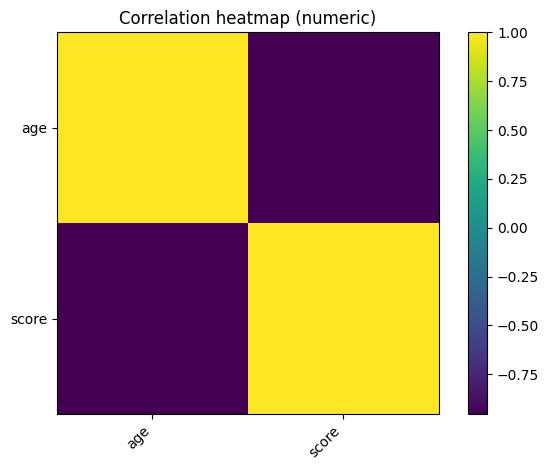

,age,score
age,1.000000,-0.953102
score,-0.953102,1.000000


In [155]:
import matplotlib.pyplot as plt
num_cols = ["age", "score"]
corr = df[num_cols].corr(numeric_only=True)

plt.figure()
plt.imshow(corr.values)
plt.title("Correlation heatmap (numeric)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

corr


### numpy is the core library for fast numerical computing in Python.

It provides the ndarray (N-dimensional array), which is like a super-powered list:

- fixed type (dtype)
- fast vector operations
- easy reshaping/slicing
- broadcasting



Common ML uses:
creating arrays of data
preprocessing
random numbers
math operations without Python loops

In [156]:
import numpy as np

x = np.array([1, 2, 3],  dtype=np.float32)
y = x * 2 + 1
print(x, y)
print("shape:", x.shape, "dtype:", x.dtype)

[1. 2. 3.] [3. 5. 7.]
shape: (3,) dtype: float32


### Printing in ML

You’ll often print metrics like loss/accuracy.

Prefer **f-strings** for clarity:
- `f"loss={loss:.4f}"`
- `f"epoch {epoch+1}/{epochs}"`


In [157]:
# A small helper to print a separator in outputs
def hr(title=""):
    print("\n" + "="*30 + (f" {title} " if title else "") + "="*30)

In [158]:
hr("Printing with f-strings")

epoch = 1
loss = 0.123456789
acc = 0.8571

print(f"Epoch {epoch}: loss={loss:.4f}, acc={acc:.2%}")   # percent format
print(f"Raw loss value: {loss}")


============================== Printing with f-strings ==============================
Epoch 1: loss=0.1235, acc=85.71%
Raw loss value: 0.123456789


## 1.1 Variables, assignment, naming conventions

A **variable** is a name that points to an object/value.

Common naming style in ML notebooks:
- `snake_case` for variables and functions: `learning_rate`, `train_loss`
- ALL_CAPS for constants: `SEED = 42`
- Avoid shadowing built-ins: don't name variables `list`, `sum`, `type`, `id`, etc.


In [159]:
hr("Variables and assignment")

# Basic assignment
epochs = 5
learning_rate = 0.01
model_name = "linear_regression_v1"
is_training = True

print(epochs, learning_rate, model_name, is_training)

# Re-assignment (same variable name, new value)
learning_rate = 0.001
print("Updated learning_rate:", learning_rate)

# Constants (convention, not enforced)
SEED = 42
print("SEED:", SEED)



============================== Variables and assignment ==============================
5 0.01 linear_regression_v1 True
Updated learning_rate: 0.001
SEED: 42


### `type()` and `id()`

- `type(x)` tells you **what kind of object** it is.
- `id(x)` is the object's identity in memory (a unique identifier *during its lifetime*).

Why this matters:
- Two variables can have the **same value** but be **different objects**.
- In ML code, bugs often happen when you accidentally share the same mutable object.


In [160]:
hr("type(), id(), == vs is")

a = [1, 2, 3]
b = [1, 2, 3]

print("type(a):", type(a))
print("a == b:", a == b)     # same values
print("a is b:", a is b)     # same object? (identity)
print("id(a):", id(a))
print("id(b):", id(b))

# Important: use `is` mainly for checking None
x = None
print("x is None:", x is None)



============================== type(), id(), == vs is ==============================
type(a): <class 'list'>
a == b: True
a is b: False
id(a): 135024201908160
id(b): 135024395264384
x is None: True


### Mutability vs immutability (super important)

- **Mutable** objects can change *in place*: `list`, `dict`, `set`
- **Immutable** objects cannot change *in place*: `int`, `float`, `bool`, `str`, `tuple`

Why ML people care:
- If two variables point to the same mutable object, changes in one place can silently affect another.
- This causes confusing bugs in datasets, config dictionaries, batch buffers, etc.


In [197]:
hr("Mutability demo: shared references")

# Two names pointing to the SAME list
loss_history = [0.9, 0.7, 0.55]
alias_history = loss_history  # not a copy!

print(loss_history is alias_history )

print("Before append:")
print("loss_history:", loss_history)
print("alias_history:", alias_history)
print("Same object?", loss_history is alias_history)

alias_history.append(0.42)  # modifies in place

print("\nAfter append via alias_history:")
print("loss_history:", loss_history)
print("alias_history:", alias_history)


============================== Mutability demo: shared references ==============================
True
Before append:
loss_history: [0.9, 0.7, 0.55]
alias_history: [0.9, 0.7, 0.55]
Same object? True

After append via alias_history:
loss_history: [0.9, 0.7, 0.55, 0.42]
alias_history: [0.9, 0.7, 0.55, 0.42]


In [162]:
hr("Copying to avoid accidental mutation")

loss_history = [0.9, 0.7, 0.55]
safe_copy = loss_history.copy()     # shallow copy (good for simple lists)

safe_copy.append(0.42)

print("Original:", loss_history)
print("Copy:", safe_copy)
print("Same object?", loss_history is safe_copy)



============================== Copying to avoid accidental mutation ==============================
Original: [0.9, 0.7, 0.55]
Copy: [0.9, 0.7, 0.55, 0.42]
Same object? False


In [163]:
hr("Immutability demo")

x = 10
y = x
print("x:", x, "id(x):", id(x))
print("y:", y, "id(y):", id(y))

y = y + 1  # creates a NEW int object
print("\nAfter y = y + 1")
print("x:", x, "id(x):", id(x))
print("y:", y, "id(y):", id(y))



============================== Immutability demo ==============================
x: 10 id(x): 11654664
y: 10 id(y): 11654664

After y = y + 1
x: 10 id(x): 11654664
y: 11 id(y): 11654696


## 1.2 Core data types

Common ML meanings:
- `int`: `epochs`, `batch_size`, `num_classes`
- `float`: `learning_rate`, `loss`, `accuracy`, `weight_decay`
- `bool`: flags like `is_train`, `use_cuda`, `shuffle`
- `str`: experiment names, paths, labels


In [164]:
hr("Core data types")

epochs = 10              # int
learning_rate = 0.001    # float
use_augmentation = False # bool
run_name = "exp_001"     # str

print(type(epochs), type(learning_rate), type(use_augmentation), type(run_name))




============================== Core data types ==============================
<class 'int'> <class 'float'> <class 'bool'> <class 'str'>


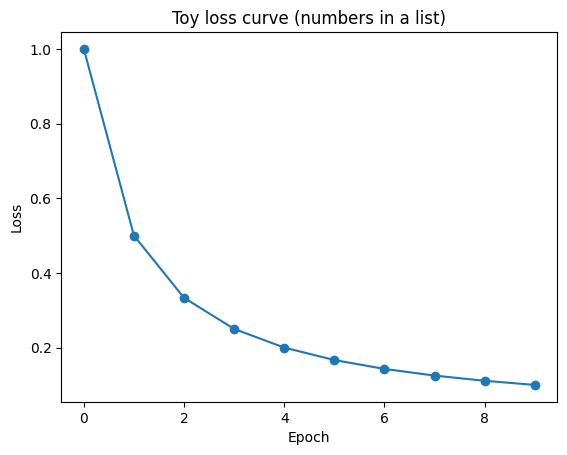

In [165]:
# ML-ish: a toy "loss curve" computed from numbers
losses = [1.0/(i+1) for i in range(epochs)]
plt.figure()
plt.plot(losses, marker="o")
plt.title("Toy loss curve (numbers in a list)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### `None` (missing / not available)

Use `None` to represent missing values or “not set yet”.

Important:
- Check with `is None` (NOT `== None`)


In [166]:
hr("None demo")

val_losses = [0.9, 0.7, None, 0.55, None, 0.42]

# Filter out missing values
clean_losses = [v for v in val_losses if v is not None]

print("Original:", val_losses)
print("Clean:", clean_losses)



============================== None demo ==============================
Original: [0.9, 0.7, None, 0.55, None, 0.42]
Clean: [0.9, 0.7, 0.55, 0.42]


### Type conversion: `int()`, `float()`, `str()`, `bool()`

Common ML case: values come as strings (from config files, CLI args, CSV).

Be careful:
- `bool("False")` is **True** because any non-empty string is truthy.


In [167]:
hr("Type conversion")

s_lr = "0.001"
lr = float(s_lr)
print("lr:", lr, type(lr))

s_epochs = "20"
epochs = int(s_epochs)
print("epochs:", epochs, type(epochs))

x = 3.14
print("str(x):", str(x), type(str(x)))

print("bool(0):", bool(0))
print("bool(1):", bool(1))
print('bool(""):', bool(""))
print('bool("False"):', bool("False"), " <-- careful!")



============================== Type conversion ==============================
lr: 0.001 <class 'float'>
epochs: 20 <class 'int'>
str(x): 3.14 <class 'str'>
bool(0): False
bool(1): True
bool(""): False
bool("False"): True  <-- careful!


## 1.3 Collections you’ll use in ML

- `list`: ordered, mutable. Great for batches, loss histories, sequences.
- `tuple`: ordered, immutable. Good for fixed shapes like `(H, W)` or returning multiple values.
- `dict`: key/value storage. Great for configs, metrics, dataset records.
- `set`: unique values. Great for unique labels, vocab, deduping.

Rule of thumb:
- If it changes over time → `list`/`dict`
- If it should never change → `tuple`
- If you want uniqueness → `set`


In [168]:
hr("list basics")

features = [0.1, 0.4, 0.35, 0.8, 0.2]
print("features:", features)

print("First item:", features[0])
print("Last item:", features[-1])
print("Slice [1:4]:", features[1:4])

features.append(0.6)
print("After append:", features)

features.extend([0.9, 0.95])
print("After extend:", features)



============================== list basics ==============================
features: [0.1, 0.4, 0.35, 0.8, 0.2]
First item: 0.1
Last item: 0.2
Slice [1:4]: [0.4, 0.35, 0.8]
After append: [0.1, 0.4, 0.35, 0.8, 0.2, 0.6]
After extend: [0.1, 0.4, 0.35, 0.8, 0.2, 0.6, 0.9, 0.95]


In [169]:
hr("tuple basics")

image_shape = (224, 224, 3)  # fixed shape (H, W, C)
print("image_shape:", image_shape, type(image_shape))

# Tuples can't be modified in place:
# image_shape[0] = 256  # would raise TypeError



============================== tuple basics ==============================
image_shape: (224, 224, 3) <class 'tuple'>


In [170]:
hr("dict basics")

config = {
    "epochs": 10,
    "learning_rate": 0.001,
    "batch_size": 32,
    "use_cuda": False,
}
pprint(config)

print("learning_rate:", config["learning_rate"])
print("momentum (with default):", config.get("momentum", 0.0))  # safe access

# Looping
for k, v in config.items():
    print(f"{k} -> {v}")



============================== dict basics ==============================
{'batch_size': 32, 'epochs': 10, 'learning_rate': 0.001, 'use_cuda': False}
learning_rate: 0.001
momentum (with default): 0.0
epochs -> 10
learning_rate -> 0.001
batch_size -> 32
use_cuda -> False


In [171]:
hr("set basics")

labels = ["cat", "dog", "cat", "bird", "dog", "fish"]
unique_labels = set(labels)

print("labels:", labels)
print("unique_labels:", unique_labels)



============================== set basics ==============================
labels: ['cat', 'dog', 'cat', 'bird', 'dog', 'fish']
unique_labels: {'cat', 'bird', 'fish', 'dog'}


## 1.4 Operators

Arithmetic: `+  -  *  /  //  %  **`  
Comparison: `== != < > <= >=`  
Logical: `and or not`  
Membership: `in`  
Identity: `is`  (use mostly with `None`)


In [172]:
hr("Operators demo")

a, b = 7, 3
print("a+b:", a+b)
print("a-b:", a-b)
print("a*b:", a*b)
print("a/b:", a/b)
print("a//b (floor division):", a//b)
print("a%b (remainder):", a%b)
print("a**b (power):", a**b)




============================== Operators demo ==============================
a+b: 10
a-b: 4
a*b: 21
a/b: 2.3333333333333335
a//b (floor division): 2
a%b (remainder): 1
a**b (power): 343


In [173]:
print("\nComparisons:")
print("a > b:", a > b)
print("a == b:", a == b)

print("\nLogical:")
is_big = (a > 5) and (b > 5)
print("is_big:", is_big)

print("\nMembership:")
vocab = {"cat", "dog", "bird"}
print("'dog' in vocab:", "dog" in vocab)

print("\nIdentity (use for None):")
x = None
print("x is None:", x is None)


Comparisons:
a > b: True
a == b: False

Logical:
is_big: False

Membership:
'dog' in vocab: True

Identity (use for None):
x is None: True


## 1.5 Indentation + control flow

Python uses **indentation** (spaces) to define blocks.
- A colon `:` starts a block (`if`, `for`, `while`, `def`, etc.)
- Keep indentation consistent (usually 4 spaces)

Control flow building blocks:
- `if / elif / else`
- `for` loops and `while` loops
- `break`: exit loop
- `continue`: skip to next iteration
- `pass`: do nothing (placeholder)


In [174]:
hr("if / elif / else")

loss = 0.42

if loss > 1.0:
    status = "bad"
elif loss > 0.5:
    status = "ok"
else:
    status = "good"

print("loss:", loss, "status:", status)



============================== if / elif / else ==============================
loss: 0.42 status: good



============================== for loop skeleton ==============================
epoch 1/8 -> loss=1.0000
epoch 2/8 -> loss=0.5000
epoch 3/8 -> loss=0.3333
epoch 4/8 -> loss=0.2500
epoch 5/8 -> loss=0.2000
epoch 6/8 -> loss=0.1667
epoch 7/8 -> loss=0.1429
epoch 8/8 -> loss=0.1250


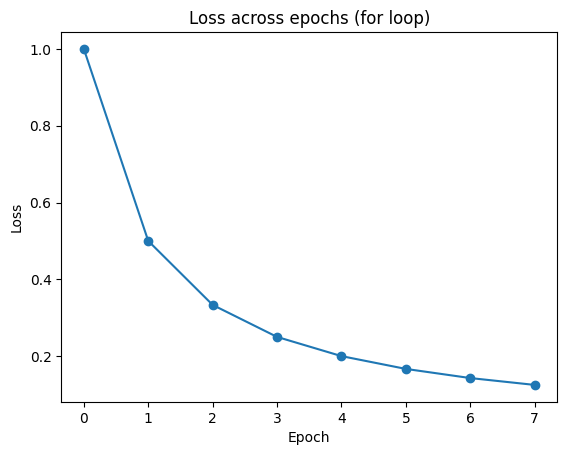

In [175]:
hr("for loop skeleton")

epochs = 8
losses = []

for epoch in range(epochs):
    # pretend this is your training step
    loss = 1.0 / (epoch + 1)
    losses.append(loss)
    print(f"epoch {epoch+1}/{epochs} -> loss={loss:.4f}")

plt.figure()
plt.plot(losses, marker="o")
plt.title("Loss across epochs (for loop)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



============================== while / break / continue / pass ==============================
Step 5: skipping (continue)
Early stop at step=9 (break)


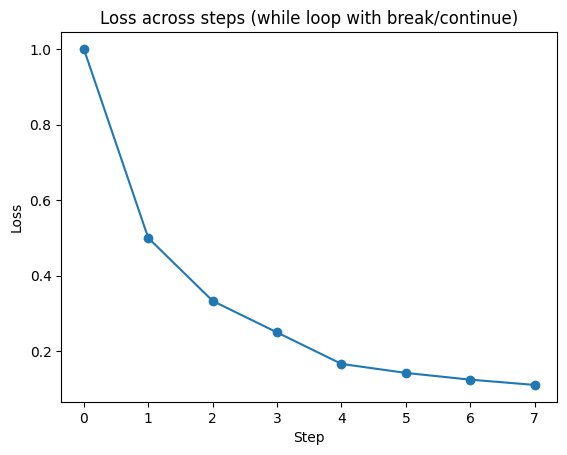

In [176]:
hr("while / break / continue / pass")

max_steps = 12
step = 0
losses = []

while step < max_steps:

    step += 1
    # Example: skip a step (maybe your batch was invalid)
    if step == 5:
        print("Step 5: skipping (continue)")
        continue

    # Example: placeholder for future code
    if step == 7:
        pass  # do nothing

    loss = 1.0 / step
    losses.append(loss)

    # Example: early stopping
    if loss < 0.12:
        print(f"Early stop at step={step} (break)")
        break



plt.figure()
plt.plot(losses, marker="o")
plt.title("Loss across steps (while loop with break/continue)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()


# 2) Functions (def, *args/**kwargs, lambda)

Functions are the *workhorse* of ML code:
- You wrap repeated logic (data prep, training steps, metrics)
- You pass settings cleanly (hyperparameters)
- You make code reusable and readable

We’ll cover:
- `def` basics + returns
- default arguments + keyword arguments
- `*args` and `**kwargs`
- scope and common gotchas
- `lambda` functions (and where they help)
- tiny ML-style examples + visualizations


## 2.1 Function fundamentals

A function:
- takes inputs (parameters)
- does work
- optionally returns an output

Why `return` matters:
- `print()` shows something to you
- `return` gives a value back to the program so you can use it later


In [177]:
hr("def basics + return vs print")

def add(a, b):
    return a + b

result = add(3, 7)
print("add(3,7) ->", result)

def add_and_print(a, b):
    print("Inside function:", a + b)

out = add_and_print(3, 7)
print("Returned value is:", out)  # will be None because there's no return



============================== def basics + return vs print ==============================
add(3,7) -> 10
Inside function: 10
Returned value is: None


### Docstrings (recommended)

A docstring is a short description inside triple quotes.
In ML notebooks, docstrings help you remember:
- expected input shapes/types
- what a function returns


In [178]:
hr("Docstring example")

def normalize_minmax(x):
    """
    Min-max normalize a 1D list/array to range [0, 1].

    Args:
        x: list or 1D numpy array of numbers

    Returns:
        numpy array with values scaled to [0, 1]
    """
    x = np.array(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

data = [3, 10, 7, 15, 2]
print("normalized:", normalize_minmax(data))



============================== Docstring example ==============================
normalized: [0.07692308 0.61538462 0.38461538 1.         0.        ]


## 2.2 Default arguments + keyword arguments

- Default arguments let you set common values.
- Keyword arguments make calls readable.

Example ML-style:
`train(model, epochs=10, lr=0.001, batch_size=32)`


In [179]:
hr("Default args + keyword args")

def train_config(epochs=10, lr=0.001, batch_size=32):
    return {"epochs": epochs, "lr": lr, "batch_size": batch_size}

print(train_config())  # uses defaults
print(train_config(epochs=5))  # override one
print(train_config(lr=0.01, batch_size=64))  # keyword overrides
print(train_config(20, 0.0005, 16))  # positional overrides (less readable)



============================== Default args + keyword args ==============================
{'epochs': 10, 'lr': 0.001, 'batch_size': 32}
{'epochs': 5, 'lr': 0.001, 'batch_size': 32}
{'epochs': 10, 'lr': 0.01, 'batch_size': 64}
{'epochs': 20, 'lr': 0.0005, 'batch_size': 16}


## 2.3 `*args` and `**kwargs`

- `*args` collects extra positional arguments into a tuple.
- `**kwargs` collects extra keyword arguments into a dict.

Why this appears in ML:
- lots of libraries accept flexible options (e.g., plotting, logging, model settings)


In [180]:
hr("*args demo")

def mean_of(*args):
    # args is a tuple
    if len(args) == 0:
        return None
    return sum(args) / len(args)

print(mean_of(1, 2, 3, 4))
print(mean_of(10))
print(mean_of())  # None



============================== *args demo ==============================
2.5
10.0
None


In [198]:
hr("*args demo")

def sum_of(a,b,*args):
    print(a,b)
    print(args, type(args))

print(sum_of(1, 2, 3, 4, 5, 6))


============================== *args demo ==============================
1 2
(3, 4, 5, 6) <class 'tuple'>
None


In [201]:
def g(x, * args, **kwargs):
    print("x:", x)
    print("args:",args)
    print("kwargs:", kwargs, type(kwargs))

g(10,151,20, lr=0.001, epochs=5, device="cuda")

x: 10
args: (151, 20)
kwargs: {'lr': 0.001, 'epochs': 5, 'device': 'cuda'} <class 'dict'>


In [183]:
def h(a, b, *args, **kwargs):
    print("a,b:", a, b)
    print("args:", args)
    print("kwargs:", kwargs)

h(1, 2, 3, 4, debug=True, lr=0.01)


a,b: 1 2
args: (3, 4)
kwargs: {'debug': True, 'lr': 0.01}


## 2.5 Lambda functions

A `lambda` is a small anonymous function:
- good for *short* logic used once
- common with `sorted(key=...)`, `map`, `filter`

Pattern:
`lambda x: expression`

Avoid using lambda for long multi-step logic — use `def`.


In [184]:
hr("lambda with sorted(key=...)")

models = [
    {"name": "A", "val_acc": 0.82},
    {"name": "B", "val_acc": 0.90},
    {"name": "C", "val_acc": 0.87},
]

# Sort by val_acc descending
best_first = sorted(models, key=lambda d: d["val_acc"], reverse=True)
print("Sorted models (best first):")
for m in best_first:
    print(m)



============================== lambda with sorted(key=...) ==============================
Sorted models (best first):
{'name': 'B', 'val_acc': 0.9}
{'name': 'C', 'val_acc': 0.87}
{'name': 'A', 'val_acc': 0.82}



============================== lambda with map + visualization ==============================


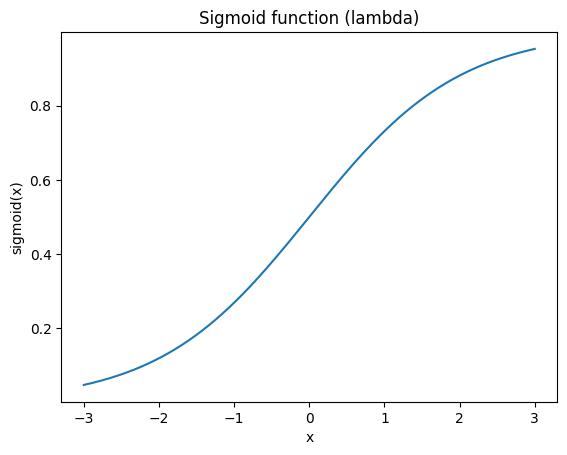

In [185]:
hr("lambda with map + visualization")

xs = np.linspace(-3, 3, 200)

# map-style transformation (vectorized numpy is better, but this shows the idea)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
ys = sigmoid(xs)

plt.figure()
plt.plot(xs, ys)
plt.title("Sigmoid function (lambda)")
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.show()


## Exercises (make new code cells)

1) Write a function `standardize(x)` that returns `(x - mean) / std`.

2) Write `safe_div(a, b, default=None)`:
- if `b == 0`, return `default`
- else return `a / b`

3) Use `sorted(..., key=lambda ...)` to sort a list of dicts by `loss`.

4) Create a plotting function `plot_xy(x, y, **kwargs)` that forwards kwargs to `plt.scatter`.


## Exercises (try in new code cells)

1) Create variables:
- `batch_size` (int)
- `dropout` (float)
- `experiment_name` (str)
- `use_gpu` (bool)

2) Make a list of 10 losses and plot it.

3) Make a dict `metrics` with keys: `loss`, `accuracy`, `epoch`.
Loop through and print `key -> value`.

4) Use a `for` loop to build `squares = [0^2, 1^2, ..., 9^2]`.


## Types (`dtype`) and conversions

Useful:
- `astype("int64")`, `astype("float32")`
- `astype("category")` for categorical columns (memory efficient)
- `pd.to_datetime(...)` for dates

## 2.6 Mini ML-style example (functions + visualization) EXTRA

We’ll simulate training a simple model `y = w*x + b` by “improving” parameters.
This is NOT full gradient descent yet — it’s a toy to show how functions organize ML code.

We’ll build:
- `predict(x, w, b)`
- `mse(y_true, y_pred)`
- `train_step(...)`
- Plot loss curve



============================== Toy dataset ==============================


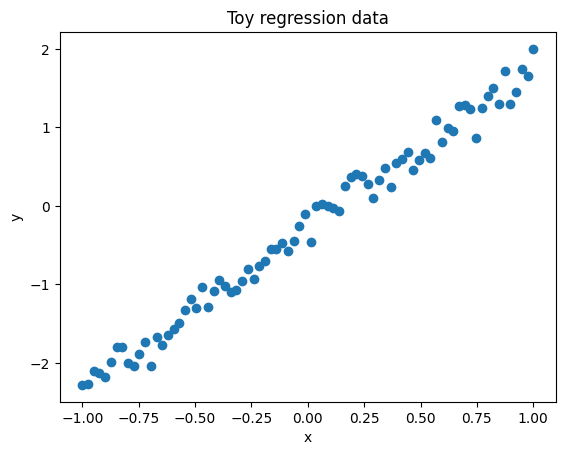

In [186]:
hr("Toy dataset")

rng = np.random.default_rng(0)
x = np.linspace(-1, 1, 80)
true_w, true_b = 2.0, -0.3
noise = rng.normal(0, 0.15, size=x.shape)
y = true_w * x + true_b + noise

plt.figure()
plt.scatter(x, y)
plt.title("Toy regression data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [187]:
hr("predict + mse")

def predict(x, w, b):
    return w * x + b

def mse(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)

# quick check
w, b = 0.0, 0.0
y_pred = predict(x, w, b)
print("Initial MSE:", mse(y, y_pred))



============================== predict + mse ==============================
Initial MSE: 1.5224437104944077


In [188]:
hr("train_step with kwargs")

def train_step(x, y, w, b, lr=0.1, **kwargs):
    """
    One toy training step.
    kwargs could carry extra options like 'clip', 'verbose', etc.
    """
    # Numerical gradient approximation (toy, slow but simple)
    eps = kwargs.get("eps", 1e-4)

    base_loss = mse(y, predict(x, w, b))

    # gradient w.r.t w
    loss_w = mse(y, predict(x, w + eps, b))
    grad_w = (loss_w - base_loss) / eps

    # gradient w.r.t b
    loss_b = mse(y, predict(x, w, b + eps))
    grad_b = (loss_b - base_loss) / eps

    # update
    w_new = w - lr * grad_w
    b_new = b - lr * grad_b

    if kwargs.get("verbose", False):
        print(f"loss={base_loss:.4f} grad_w={grad_w:.4f} grad_b={grad_b:.4f}")

    return w_new, b_new, base_loss

# Run a few steps
w, b = 0.0, 0.0
w, b, loss0 = train_step(x, y, w, b, lr=0.5, verbose=True)
print("Updated w,b:", w, b, "loss:", loss0)



============================== train_step with kwargs ==============================
loss=1.5224 grad_w=-1.3945 grad_b=0.5640
Updated w,b: 0.6972690503326273 -0.28199868961187313 loss: 1.5224437104944077



============================== Training loop ==============================
Learned params: 2.0401575916987866 -0.2819986896112764


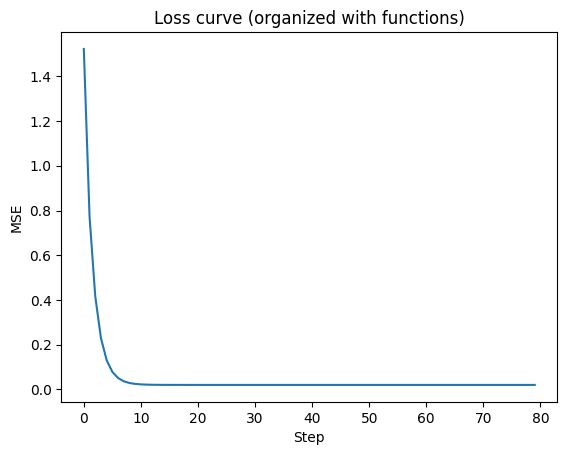

In [189]:
hr("Training loop")

def train(x, y, steps=60, lr=0.3, **kwargs):
    w, b = 0.0, 0.0
    losses = []
    for step in range(steps):
        w, b, loss = train_step(x, y, w, b, lr=lr, **kwargs)
        losses.append(loss)
    return w, b, losses

w_hat, b_hat, losses = train(x, y, steps=80, lr=0.4, eps=1e-4)

print("Learned params:", w_hat, b_hat)

plt.figure()
plt.plot(losses)
plt.title("Loss curve (organized with functions)")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()



============================== Fit visualization ==============================


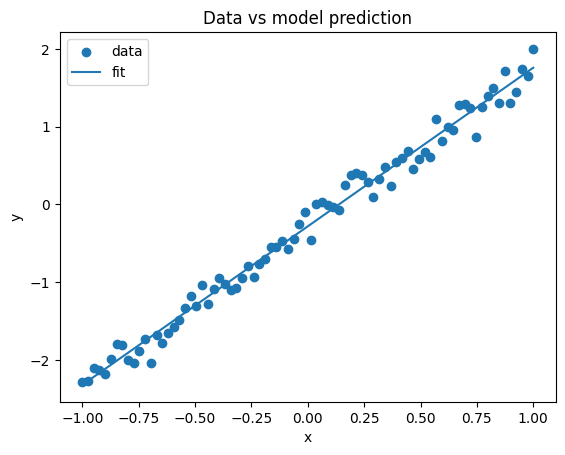

In [190]:
hr("Fit visualization")

y_fit = predict(x, w_hat, b_hat)

plt.figure()
plt.scatter(x, y, label="data")
plt.plot(x, y_fit, label="fit")
plt.title("Data vs model prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
